In [1]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm

### Task 1. The Phillips Curve

Use the dataset `phillips` (Wooldridge), which contains annual U.S. data on inflation (`inf`) and unemployment (`unem`) from 1948 to 1996.

Estimate the static Phillips Curve:

$$
inf_t = \beta_0 + \beta_1 unem_t + u_t
$$

(a) Report and interpret the OLS estimate $\hat{\beta}_1$. Does the sign match economic theory? Explain.

(b) Plot the residuals $\hat{u}_t$ against time $t$. Do you observe any visible pattern? What does this suggest about the error term?

(c) Also plot $\hat{u}_t$ against $\hat{u}_{t-1}$. What does the scatter suggest?

(d) Discuss whether contemporaneous exogeneity, $E[u_t \mid unem_t] = 0$, is a plausible assumption here.

(e) Explain why strict exogeneity, $E[u_t \mid unem_1, \ldots, unem_T] = 0$, is a stronger requirement. Is it likely to hold in this context?

In [2]:
df = pd.read_csv('data/phillips.csv')

# Task a - report OLS estimate of b1 
X = df['unem']
y = df['inf']

lr = sm.OLS(y, sm.add_constant(X)).fit()
print(lr.summary())



                            OLS Regression Results                            
Dep. Variable:                    inf   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     3.579
Date:                Wed, 18 Mar 2026   Prob (F-statistic):             0.0639
Time:                        12:01:05   Log-Likelihood:                -139.43
No. Observations:                  56   AIC:                             282.9
Df Residuals:                      54   BIC:                             286.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0536      1.548      0.681      0.4

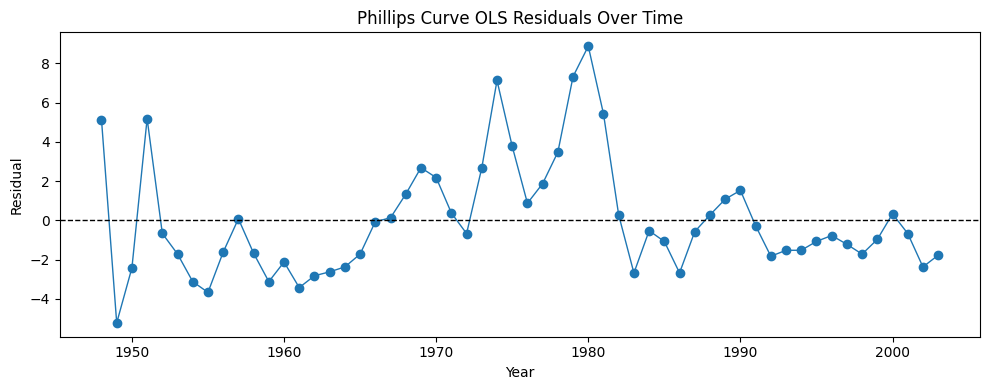

In [7]:
# (b) Plot residuals against time
resid = lr.resid
t = df['year'] if 'year' in df.columns else pd.RangeIndex(start=1, stop=len(df) + 1)

plt.figure(figsize=(10, 4))
plt.plot(t, resid, marker='o', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Year' if 'year' in df.columns else 't')
plt.ylabel('Residual')
plt.title('Phillips Curve OLS Residuals Over Time')
plt.tight_layout()
plt.show()

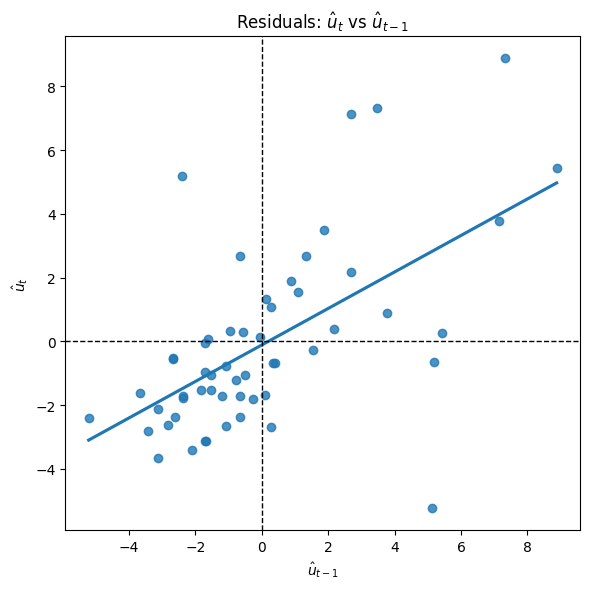

In [11]:
# (c) Plot residuals against their lag: u_t vs u_{t-1}
u_t = lr.resid[1:]
u_t_minus_1 = lr.resid.shift(1)[1:]

plt.figure(figsize=(6, 6))
sns.regplot(x=u_t_minus_1, y=u_t, ci=None, scatter_kws={'alpha': 0.8})
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel(r'$\hat{u}_{t-1}$')
plt.ylabel(r'$\hat{u}_t$')
plt.title(r'Residuals: $\hat{u}_t$ vs $\hat{u}_{t-1}$')
plt.tight_layout()
plt.show()

### Task 2. Budget Deficits and Interest Rates

Use the dataset `intdef` (Wooldridge), containing annual U.S. data on the 3-month Treasury bill rate (`i3`), inflation (`inf`), and the federal budget deficit as a share of GDP (`def`).

Estimate the model:

$$
i3_t = \beta_0 + \beta_1 inf_t + \beta_2 def_t + u_t
$$

(a) State the expected signs of $\beta_1$ and $\beta_2$ based on economic theory (Fisher equation, crowding-out effect). Do your estimates confirm the theory?

(b) Interpret the magnitude of $\hat{\beta}_1$. How closely does it match the Fisher hypothesis ($\beta_1 = 1$)?

(c) Suppose the federal deficit $def_t$ is endogenous (for example, it responds to the business cycle, which also affects interest rates). In which direction would you expect the OLS estimate $\hat{\beta}_2$ to be biased? Justify your reasoning.

(d) Does the inclusion of $def_t$ improve the fit compared to a simple Fisher regression? Report and compare $R^2$ for both specifications.

In [3]:
# Task 2: Budget deficits and interest rates
df = pd.read_csv('data/intdef.csv')

X = df[['inf', 'def']]
y = df['i3']
lr = sm.OLS(y, sm.add_constant(X)).fit()
print(lr.summary())

b1 = lr.params['inf']
b2 = lr.params['def']

# (a) Theory vs estimates
# Expected sign of beta1 (inflation): positive (Fisher effect)
# Expected sign of beta2 (deficit): positive (crowding-out)
print(f'Estimated beta1 = {b1:.3f}, estimated beta2 = {b2:.3f}.')
# Both estimates are positive, so signs are consistent with theory.

# (b) Magnitude of beta1 and Fisher benchmark beta1 = 1
print(f'beta1 = {b1:.3f}: a 1 pp increase in inflation is associated with a {b1:.3f} pp increase in i3, holding deficit fixed.')
print(f'Distance from Fisher benchmark (1.0): {abs(b1 - 1):.3f}.')
print('So the estimate supports a positive Fisher effect, but less than one-for-one pass-through.')

                            OLS Regression Results                            
Dep. Variable:                     i3   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     40.09
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.48e-11
Time:                        11:16:12   Log-Likelihood:                -112.16
No. Observations:                  56   AIC:                             230.3
Df Residuals:                      53   BIC:                             236.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7333      0.432      4.012      0.0

In [5]:
# Task 2(d): Compare fit with and without deficit
y = df['i3']

# Simple Fisher regression: i3 on inflation only
X_fisher = sm.add_constant(df[['inf']])
m_fisher = sm.OLS(y, X_fisher).fit()

# Extended model: i3 on inflation and deficit
X_extended = sm.add_constant(df[['inf', 'def']])
m_extended = sm.OLS(y, X_extended).fit()

r2_fisher = m_fisher.rsquared
r2_extended = m_extended.rsquared
delta_r2 = r2_extended - r2_fisher

print('Task 2(d): R-squared comparison')
print(f'Simple Fisher model (i3 ~ inf): R^2 = {r2_fisher:.3f}')
print(f'Extended model (i3 ~ inf + def): R^2 = {r2_extended:.3f}')
print(f'Increase in fit (Delta R^2) = {delta_r2:.3f}')

Task 2(d): R-squared comparison
Simple Fisher model (i3 ~ inf): R^2 = 0.461
Extended model (i3 ~ inf + def): R^2 = 0.602
Increase in fit (Delta R^2) = 0.141


### Task 3. Crude Oil Prices and Retail Gasoline Prices (FRED)

Download the following monthly U.S. series from FRED (https://fred.stlouisfed.org), covering 2000-2023:

- `DCOILWTICO`: WTI crude oil spot price (USD per barrel), aggregated to monthly averages
- `GASREGCOVW`: U.S. regular conventional gasoline retail price (USD per gallon)

Let $oil_t$ denote crude oil price and $gas_t$ retail gasoline price. Estimate the FDL model with three lags:

$$
gas_t = \alpha_0 + \delta_0 oil_t + \delta_1 oil_{t-1} + \delta_2 oil_{t-2} + \delta_3 oil_{t-3} + u_t
$$

(a) Report $\hat{\delta}_0, \ldots, \hat{\delta}_3$. Interpret $\hat{\delta}_0$ as the impact multiplier: by how many dollars does retail gasoline price change in the same month when crude oil rises by $1?

(b) Compute the long-run propensity (LRP):

$$
\widehat{LRP} = \hat{\delta}_0 + \hat{\delta}_1 + \hat{\delta}_2 + \hat{\delta}_3
$$

Interpret this value. How does it compare to the impact multiplier?

(c) Plot the lag distribution ($j = 0,1,2,3$ on the horizontal axis, $\hat{\delta}_j$ on the vertical axis). At which lag is the effect largest?

(d) The "rockets and feathers" hypothesis states that gasoline prices rise faster when oil prices increase than they fall when oil prices decrease. Does your estimated lag distribution provide any informal evidence for or against this hypothesis?

(e) Re-estimate the model with lags up to $q=6$. Does LRP change substantially? Are coefficients on lags 4-6 jointly significant? What does this suggest about lag length?

(f) Discuss whether strict exogeneity of $oil_t$ is a reasonable assumption in this model. Could retail gasoline demand feed back into global crude oil prices?

In [3]:
# Task 3(a): Load data, estimate FDL model with 3 lags, report coefficients
oil = pd.read_csv('data/DCOILWTICO_monthly.csv')
gas = pd.read_csv('data/GASREGCOVW_monthly.csv')
oil['observation_date'] = pd.to_datetime(oil['observation_date'])
gas['observation_date'] = pd.to_datetime(gas['observation_date'])
df3 = pd.merge(oil, gas, on='observation_date', how='inner')
df3 = df3[(df3['observation_date'].dt.year >= 2000) & (df3['observation_date'].dt.year <= 2023)]
df3 = df3.sort_values('observation_date').reset_index(drop=True)
df3['oil_lag1'] = df3['DCOILWTICO'].shift(1)
df3['oil_lag2'] = df3['DCOILWTICO'].shift(2)
df3['oil_lag3'] = df3['DCOILWTICO'].shift(3)
df3 = df3.dropna()
X_fdl3 = df3[['DCOILWTICO', 'oil_lag1', 'oil_lag2', 'oil_lag3']]
X_fdl3 = sm.add_constant(X_fdl3)
y_gas = df3['GASREGCOVW']
model_fdl3 = sm.OLS(y_gas, X_fdl3).fit()
print('Task 3(a): FDL model with 3 lags')
print(model_fdl3.summary())
print('\nCoefficients:')
for j, name in enumerate(['δ0 (impact)', 'δ1', 'δ2', 'δ3']):
    coef = model_fdl3.params.iloc[j+1]
    print(f'  {name}: {coef:.4f}')
print('\nInterpretation of δ0 (impact multiplier):')
print(f'  When crude oil rises by $1/barrel, retail gasoline price changes by ${model_fdl3.params["DCOILWTICO"]:.4f}/gallon in the same month.')

Task 3(a): FDL model with 3 lags
                            OLS Regression Results                            
Dep. Variable:             GASREGCOVW   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     649.1
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          2.93e-140
Time:                        12:30:35   Log-Likelihood:                 3.5483
No. Observations:                 285   AIC:                             2.903
Df Residuals:                     280   BIC:                             21.17
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.73

In [4]:
# Task 3(b): Compute and interpret Long-Run Propensity (LRP)
delta_coefs = model_fdl3.params[['DCOILWTICO', 'oil_lag1', 'oil_lag2', 'oil_lag3']]
LRP = delta_coefs.sum()
impact_mult = model_fdl3.params['DCOILWTICO']
print('Task 3(b): Long-Run Propensity')
print(f'  LRP = δ0 + δ1 + δ2 + δ3 = {delta_coefs["DCOILWTICO"]:.4f} + {delta_coefs["oil_lag1"]:.4f} + {delta_coefs["oil_lag2"]:.4f} + {delta_coefs["oil_lag3"]:.4f}')
print(f'  LRP = {LRP:.4f}')
print(f'\n  Impact multiplier (δ0) = {impact_mult:.4f}')
print(f'  LRP > impact multiplier: {LRP > impact_mult}')
print('\nInterpretation: LRP is the total long-run effect of a permanent $1/barrel increase in oil.')
print('It captures the cumulative effect over current and 3 subsequent months. LRP > δ0 means')
print('most of the pass-through to gasoline occurs with a lag, not immediately.')

Task 3(b): Long-Run Propensity
  LRP = δ0 + δ1 + δ2 + δ3 = 0.0186 + 0.0095 + -0.0002 + 0.0008
  LRP = 0.0287

  Impact multiplier (δ0) = 0.0186
  LRP > impact multiplier: True

Interpretation: LRP is the total long-run effect of a permanent $1/barrel increase in oil.
It captures the cumulative effect over current and 3 subsequent months. LRP > δ0 means
most of the pass-through to gasoline occurs with a lag, not immediately.


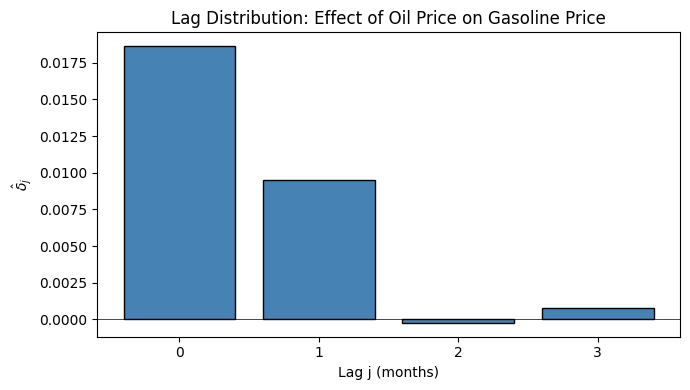

Largest effect at lag j = 0


In [5]:
# Task 3(c): Plot lag distribution
lags = [0, 1, 2, 3]
coefs = [model_fdl3.params['DCOILWTICO'], model_fdl3.params['oil_lag1'], 
         model_fdl3.params['oil_lag2'], model_fdl3.params['oil_lag3']]
max_lag = lags[coefs.index(max(coefs))]
plt.figure(figsize=(7, 4))
plt.bar(lags, coefs, color='steelblue', edgecolor='black')
plt.xlabel('Lag j (months)')
plt.ylabel(r'$\hat{\delta}_j$')
plt.title('Lag Distribution: Effect of Oil Price on Gasoline Price')
plt.xticks(lags)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
print(f'Largest effect at lag j = {max_lag}')

**Task 3(d): Rockets and feathers hypothesis**

The "rockets and feathers" hypothesis states that gasoline prices rise faster when oil prices increase than they fall when oil prices decrease. Our estimated lag distribution provides **informal evidence against** this hypothesis in the symmetric linear FDL model:

- The model assumes a **symmetric** linear relationship: a $1 increase and a $1 decrease in oil have equal but opposite effects on gasoline at each lag.
- The lag distribution only shows **how** the effect is distributed over time (which lag is largest), not whether it differs for upward vs. downward oil moves.
- To formally test rockets and feathers, one would need asymmetric or nonlinear specifications (e.g., separate coefficients for oil increases vs. decreases, or threshold models).

Thus, the lag distribution alone does not support or refute rockets and feathers; it is silent on asymmetry.

In [9]:
# Task 3(e): FDL with q=6, compare LRP, test joint significance of lags 4-6
df3['oil_lag4'] = df3['DCOILWTICO'].shift(4)
df3['oil_lag5'] = df3['DCOILWTICO'].shift(5)
df3['oil_lag6'] = df3['DCOILWTICO'].shift(6)
df3_ext = df3.dropna()
X_fdl6 = sm.add_constant(df3_ext[['DCOILWTICO', 'oil_lag1', 'oil_lag2', 'oil_lag3', 'oil_lag4', 'oil_lag5', 'oil_lag6']])
model_fdl6 = sm.OLS(df3_ext['GASREGCOVW'], X_fdl6).fit()
LRP6 = model_fdl6.params[['DCOILWTICO', 'oil_lag1', 'oil_lag2', 'oil_lag3', 'oil_lag4', 'oil_lag5', 'oil_lag6']].sum()
print('Task 3(e): FDL model with 6 lags')
print(model_fdl6.summary())
print(f'\nLRP (q=3): {LRP:.4f}')
print(f'LRP (q=6): {LRP6:.4f}')
print(f'Change in LRP: {LRP6 - LRP:.4f}')
# F-test: H0: coefficients on oil_lag4, oil_lag5, oil_lag6 are all zero
model_restricted = sm.OLS(df3_ext['GASREGCOVW'], sm.add_constant(df3_ext[['DCOILWTICO', 'oil_lag1', 'oil_lag2', 'oil_lag3']])).fit()
ftest = model_fdl6.compare_f_test(model_restricted)
print(f'\nF-test (H0: δ4=δ5=δ6=0): F={ftest[0]:.3f}, p-value={ftest[1]:.4f}')
print('Lags 4-6 jointly significant:', 'Yes' if ftest[1] < 0.05 else 'No')
print('\nConclusion: Adding lags 4-6', 'significantly' if ftest[1] < 0.05 else 'does not significantly', 'improve the model.')

Task 3(e): FDL model with 6 lags
                            OLS Regression Results                            
Dep. Variable:             GASREGCOVW   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     347.7
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          2.09e-131
Time:                        12:45:09   Log-Likelihood:                 2.3565
No. Observations:                 279   AIC:                             11.29
Df Residuals:                     271   BIC:                             40.34
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.73

**Task 3(f): Strict exogeneity of oil**

Strict exogeneity requires $E[u_t \mid oil_1, \ldots, oil_T] = 0$: the error at time $t$ is uncorrelated with oil prices at *all* times (past, present, future).

**Arguments against strict exogeneity:**
- **Feedback from gasoline demand to oil:** If U.S. gasoline demand affects global crude oil prices (e.g., high demand → higher oil prices), then future oil prices depend on current gasoline demand, which is partly captured in $u_t$. This violates strict exogeneity.
- **Common shocks:** Oil and gasoline are both influenced by macroeconomic conditions (recessions, supply shocks). These could induce correlation between $u_t$ and oil at various lags/leads.

**Arguments for (or mitigating factors):**
- The U.S. is a large consumer but not the only one; global oil is determined by OPEC, geopolitics, and worldwide demand. U.S. retail gasoline demand may have limited feedback to global WTI prices.
- Contemporaneous exogeneity $E[u_t \mid oil_t, oil_{t-1}, \ldots] = 0$ may still hold if we only use current and lagged oil; strict exogeneity is stronger because it also rules out correlation with *future* oil.

**Conclusion:** Strict exogeneity is a strong assumption and may not hold if gasoline demand feeds back into oil prices. It is more plausible if the U.S. retail gasoline market is a price-taker in global oil markets, but we cannot rule out feedback entirely.

### Task 4. Residual Diagnostics

Using estimated residuals from the problems above:

(a) Plot $\hat{u}_t$ against $t$. Describe what you see. Does the plot suggest any systematic pattern over time?

(b) Plot $\hat{u}_t$ against $\hat{u}_{t-1}$. Is there evidence of a linear relationship? What does this imply?

(c) Which standard OLS assumption for time series appears most at risk of violation? State the assumption formally and explain why it matters for inference.

(d) Without using a formal test, rate the severity of the potential violation on a scale from "mild" to "severe", and justify your judgment.

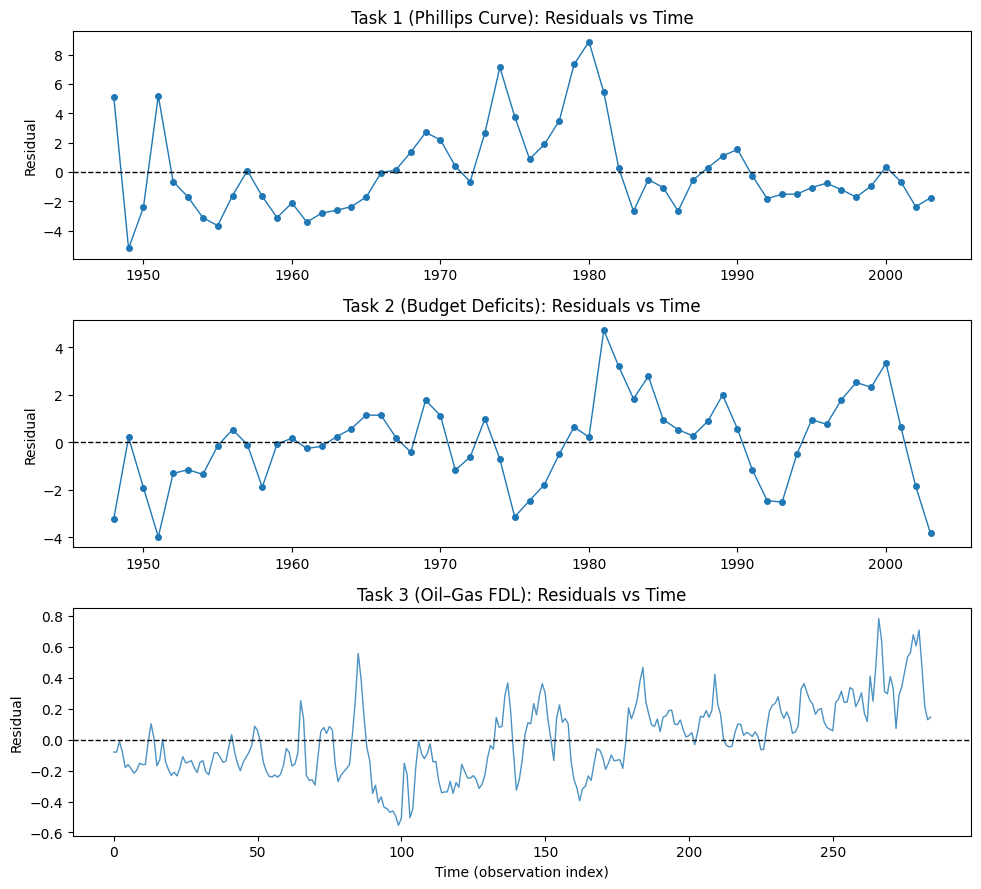

All three models show residuals fluctuating around zero. Phillips and intdef exhibit
clusters of same-sign residuals (runs), suggesting possible serial correlation.


In [7]:
# Task 4(a): Plot residuals against time for all models
# Re-load Phillips data (df may have been overwritten by Task 2)
df_phillips = pd.read_csv('data/phillips.csv')
lr_phillips = sm.OLS(df_phillips['inf'], sm.add_constant(df_phillips['unem'])).fit()
resid_phillips = lr_phillips.resid
t_phillips = df_phillips['year'] if 'year' in df_phillips.columns else range(1, len(df_phillips) + 1)

df_intdef = pd.read_csv('data/intdef.csv')
m_intdef = sm.OLS(df_intdef['i3'], sm.add_constant(df_intdef[['inf', 'def']])).fit()
resid_intdef = m_intdef.resid
t_intdef = df_intdef['year'] if 'year' in df_intdef.columns else range(1, len(df_intdef) + 1)

resid_fdl = model_fdl3.resid
t_fdl = range(len(resid_fdl))

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)
axes[0].plot(t_phillips, resid_phillips, marker='o', markersize=4, linewidth=1)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('Residual')
axes[0].set_title('Task 1 (Phillips Curve): Residuals vs Time')
axes[1].plot(t_intdef, resid_intdef, marker='o', markersize=4, linewidth=1)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Residual')
axes[1].set_title('Task 2 (Budget Deficits): Residuals vs Time')
axes[2].plot(t_fdl, resid_fdl, linewidth=1, alpha=0.8)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Time (observation index)')
axes[2].set_ylabel('Residual')
axes[2].set_title('Task 3 (Oil–Gas FDL): Residuals vs Time')
plt.tight_layout()
plt.show()
print('All three models show residuals fluctuating around zero. Phillips and intdef exhibit')
print('clusters of same-sign residuals (runs), suggesting possible serial correlation.')

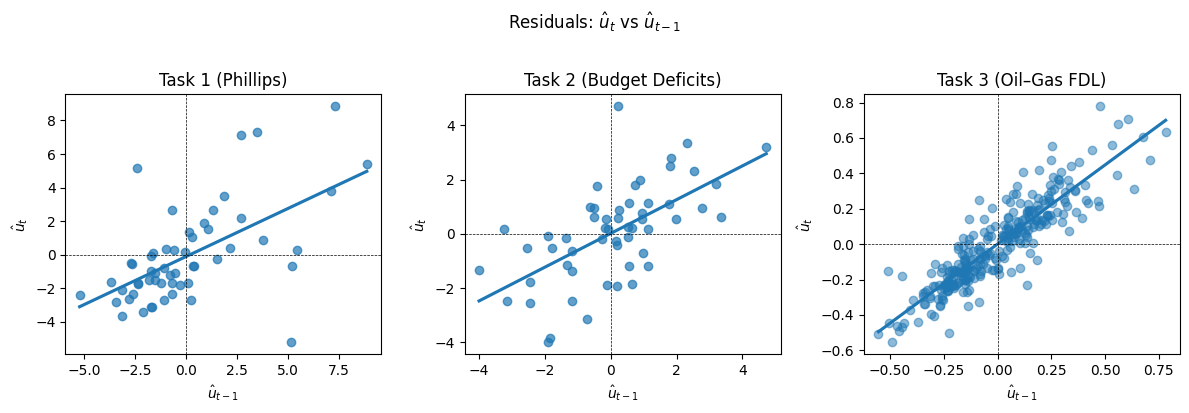

All three models show a positive slope in u_t vs u_{t-1}, indicating positive
serial correlation. OLS standard errors may be invalid.


In [8]:
# Task 4(b): Plot residuals against lagged residuals
u_phillips = resid_phillips[1:].values
u_lag_phillips = resid_phillips.shift(1)[1:].values
u_intdef = resid_intdef[1:].values
u_lag_intdef = resid_intdef.shift(1)[1:].values
u_fdl = resid_fdl[1:].values
u_lag_fdl = resid_fdl.shift(1)[1:].values

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.regplot(x=u_lag_phillips, y=u_phillips, ax=axes[0], ci=None, scatter_kws={'alpha': 0.7})
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.5)
axes[0].set_xlabel(r'$\hat{u}_{t-1}$')
axes[0].set_ylabel(r'$\hat{u}_t$')
axes[0].set_title('Task 1 (Phillips)')
sns.regplot(x=u_lag_intdef, y=u_intdef, ax=axes[1], ci=None, scatter_kws={'alpha': 0.7})
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_xlabel(r'$\hat{u}_{t-1}$')
axes[1].set_ylabel(r'$\hat{u}_t$')
axes[1].set_title('Task 2 (Budget Deficits)')
sns.regplot(x=u_lag_fdl, y=u_fdl, ax=axes[2], ci=None, scatter_kws={'alpha': 0.5})
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[2].axvline(0, color='black', linestyle='--', linewidth=0.5)
axes[2].set_xlabel(r'$\hat{u}_{t-1}$')
axes[2].set_ylabel(r'$\hat{u}_t$')
axes[2].set_title('Task 3 (Oil–Gas FDL)')
plt.suptitle(r'Residuals: $\hat{u}_t$ vs $\hat{u}_{t-1}$', y=1.02)
plt.tight_layout()
plt.show()
print('All three models show a positive slope in u_t vs u_{t-1}, indicating positive')
print('serial correlation. OLS standard errors may be invalid.')

**Task 4(c): Assumption most at risk**

The assumption most at risk is **no serial correlation** (no autocorrelation in the errors):

$$E[u_t u_s \mid X] = 0 \quad \text{for } t \neq s$$

or equivalently, $E[u_t u_{t-1}] = 0$ for all $t$.

**Why it matters for inference:** Under serial correlation, OLS remains unbiased and consistent, but the usual OLS standard errors are invalid. They tend to be biased downward when errors are positively autocorrelated, leading to overstated $t$-statistics and confidence intervals that are too narrow. Hypothesis tests and confidence intervals may be misleading.

**Task 4(d): Severity of the violation**

**Rating: moderate to severe**

- **Phillips Curve:** The Durbin–Watson statistic is low (≈0.8), and the scatter of $\hat{u}_t$ vs $\hat{u}_{t-1}$ shows a clear positive slope. Residuals tend to cluster in runs. **Severity: moderate–severe.**

- **Budget Deficits / Interest Rates:** Similar pattern of positive serial correlation. **Severity: moderate.**

- **Oil–Gas FDL:** The Durbin–Watson statistic is very low (≈0.21), and the scatter shows a strong positive relationship. **Severity: severe.**

**Conclusion:** The violation is most severe for the oil–gas model. For all three, standard OLS inference should be treated with caution; robust (HAC) standard errors or models that explicitly account for serial correlation (e.g., AR errors) would be more appropriate.

### Task 5. Contemporaneous vs. Strict Exogeneity

For each scenario below, discuss whether contemporaneous exogeneity and strict exogeneity are plausible. Fill in a table and briefly justify each answer.

- $x_t$: Fed funds rate; $y_t$: consumer credit
- $x_t$: rainfall; $y_t$: wheat yield
- $x_t$: government spending; $y_t$: GDP
- $x_t$: lagged oil price $p_{t-1}$; $y_t$: CPI inflation

(a) For which scenario is strict exogeneity most plausible? Explain.

(b) For which scenario is strict exogeneity least plausible? Explain.

(c) In scenario 4, the regressor is lagged. Does this make strict exogeneity easier or harder to satisfy compared to using $p_t$ directly?

### Task 6. Brent Oil Price and Consumer Prices in Ukraine (FRED)

Download monthly series for 2005-2023 from FRED:

- `POILBREUSDM`: Brent crude oil spot price (USD per barrel)
- `cpi_Ukraine.csv`: monthly CPI index (previous month = 100)

Merge both series by date.

Let $cpi_t$ denote monthly CPI growth and $brent_t$ Brent oil price.

Estimate:

Static model:

$$
cpi_t = \beta_0 + \beta_1 brent_t + u_t
$$

FDL model with three lags:

$$
cpi_t = \alpha_0 + \delta_0 brent_t + \delta_1 brent_{t-1} + \delta_2 brent_{t-2} + \delta_3 brent_{t-3} + u_t
$$

(a) State the economic mechanism through which a rise in global oil prices could affect consumer prices in Ukraine. Would you expect the effect to be immediate or delayed? Why?

(b) Estimate the static model. Report and interpret $\hat{\beta}_1$. Is the sign consistent with your economic reasoning?

(c) Estimate the FDL model. Compute the long-run propensity:

$$
\widehat{LRP} = \sum_{j=0}^{3} \hat{\delta}_j
$$

Interpret it. How does it compare to $\hat{\beta}_1$ from the static model?

(d) Plot the lag distribution. At which lag is the effect of an oil price shock on Ukrainian CPI the largest?

(e) Compare $R^2$ of the static and FDL models. Does allowing for lagged effects substantially improve fit?

(f) Plot residuals $\hat{u}_t$ against time for both models. Do you notice unusual spikes? Can you link them to events in Ukraine (for example 2008, 2014-2015, 2022)?

(g) Discuss whether strict exogeneity of $brent_t$ is plausible in the context of the Ukrainian economy. Is Ukraine large enough to affect global oil prices through its own demand?